<h1>HIV/SIDA National Atitude

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind
import statsmodels.formula.api as smf
from scipy.stats import ttest_ind, chi2_contingency

In [2]:
data = pd.read_csv("dataset/hiv-attitudes_national_tls.csv")

data.drop(['RegionId', 'CILow', 'ByVariableLabel', 'CIHigh', 'LevelRank'], axis=1, inplace=True)

data

,ISO3,DataId,Indicator,Value,Precision,DHS_CountryCode,CountryName,SurveyYear,SurveyId,IndicatorId,...,CharacteristicCategory,CharacteristicLabel,ByVariableId,IsTotal,IsPreferred,SDRID,SurveyYearLabel,SurveyType,DenominatorWeighted,DenominatorUnweighted
0,#country+code,#meta+id,#indicator+name,#indicator+value+num,#indicator+precision,NaN,#country+name,#date+year,#survey+id,#indicator+code,...,NaN,NaN,#indicator+label+code,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,TLS,461070,Accepting attitudes - Willing to care for fami...,55,1,TL,Timor-Leste,2009,TL2009DHS,HA_AATT_W_CRE,...,Total 15-49,Total 15-49,0,1.0,1.0,HAAATTWCRE,2009-10,DHS,5748.0,5397.0
2,TLS,461071,Accepting attitudes - Would buy fresh vegetabl...,34.2,1,TL,Timor-Leste,2009,TL2009DHS,HA_AATT_W_VEG,...,Total 15-49,Total 15-49,0,1.0,1.0,HAAATTWVEG,2009-10,DHS,5748.0,5397.0
3,TLS,461073,Accepting attitudes - Female teacher who is HI...,44.2,1,TL,Timor-Leste,2009,TL2009DHS,HA_AATT_W_FTC,...,Total 15-49,Total 15-49,0,1.0,1.0,HAAATTWFTC,2009-10,DHS,5748.0,5397.0
4,TLS,461072,Accepting attitudes - Not secretive about fami...,84.1,1,TL,Timor-Leste,2009,TL2009DHS,HA_AATT_W_SEC,...,Total 15-49,Total 15-49,0,1.0,1.0,HAAATTWSEC,2009-10,DHS,5748.0,5397.0
5,TLS,461104,Accepting attitudes towards those living with ...,11.1,1,TL,Timor-Leste,2009,TL2009DHS,HA_AATT_W_AAT,...,Total 15-49,Total 15-49,0,1.0,1.0,HAAATTWAAT,2009-10,DHS,5748.0,5397.0
6,TLS,468218,Number of women who have heard of AIDS,5748,0,TL,Timor-Leste,2009,TL2009DHS,HA_AATT_W_NUM,...,Total 15-49,Total 15-49,0,1.0,1.0,HAAATTWNUM,2009-10,DHS,NaN,5397.0
7,TLS,285178,Number of women who have heard of AIDS (unweig...,5397,0,TL,Timor-Leste,2009,TL2009DHS,HA_AATT_W_UNW,...,Total 15-49,Total 15-49,0,1.0,1.0,HAAATTWUNW,2009-10,DHS,5748.0,NaN
8,TLS,687147,Accepting attitudes - Willing to care for fami...,26.4,1,TL,Timor-Leste,2009,TL2009DHS,HA_AATT_M_CRE,...,Total 15-49,Total 15-49,0,1.0,1.0,HAAATTMCRE,2009-10,DHS,2474.0,2442.0
9,TLS,687148,Accepting attitudes - Would buy fresh vegetabl...,21.8,1,TL,Timor-Leste,2009,TL2009DHS,HA_AATT_M_VEG,...,Total 15-49,Total 15-49,0,1.0,1.0,HAAATTMVEG,2009-10,DHS,2474.0,2442.0


In [3]:

# Quick overview
display(data.head(8))
print(data.shape)
print(data.columns.tolist())


,ISO3,DataId,Indicator,Value,Precision,DHS_CountryCode,CountryName,SurveyYear,SurveyId,IndicatorId,...,CharacteristicCategory,CharacteristicLabel,ByVariableId,IsTotal,IsPreferred,SDRID,SurveyYearLabel,SurveyType,DenominatorWeighted,DenominatorUnweighted
0,#country+code,#meta+id,#indicator+name,#indicator+value+num,#indicator+precision,NaN,#country+name,#date+year,#survey+id,#indicator+code,...,NaN,NaN,#indicator+label+code,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,TLS,461070,Accepting attitudes - Willing to care for fami...,55,1,TL,Timor-Leste,2009,TL2009DHS,HA_AATT_W_CRE,...,Total 15-49,Total 15-49,0,1.0,1.0,HAAATTWCRE,2009-10,DHS,5748.0,5397.0
2,TLS,461071,Accepting attitudes - Would buy fresh vegetabl...,34.2,1,TL,Timor-Leste,2009,TL2009DHS,HA_AATT_W_VEG,...,Total 15-49,Total 15-49,0,1.0,1.0,HAAATTWVEG,2009-10,DHS,5748.0,5397.0
3,TLS,461073,Accepting attitudes - Female teacher who is HI...,44.2,1,TL,Timor-Leste,2009,TL2009DHS,HA_AATT_W_FTC,...,Total 15-49,Total 15-49,0,1.0,1.0,HAAATTWFTC,2009-10,DHS,5748.0,5397.0
4,TLS,461072,Accepting attitudes - Not secretive about fami...,84.1,1,TL,Timor-Leste,2009,TL2009DHS,HA_AATT_W_SEC,...,Total 15-49,Total 15-49,0,1.0,1.0,HAAATTWSEC,2009-10,DHS,5748.0,5397.0
5,TLS,461104,Accepting attitudes towards those living with ...,11.1,1,TL,Timor-Leste,2009,TL2009DHS,HA_AATT_W_AAT,...,Total 15-49,Total 15-49,0,1.0,1.0,HAAATTWAAT,2009-10,DHS,5748.0,5397.0
6,TLS,468218,Number of women who have heard of AIDS,5748,0,TL,Timor-Leste,2009,TL2009DHS,HA_AATT_W_NUM,...,Total 15-49,Total 15-49,0,1.0,1.0,HAAATTWNUM,2009-10,DHS,NaN,5397.0
7,TLS,285178,Number of women who have heard of AIDS (unweig...,5397,0,TL,Timor-Leste,2009,TL2009DHS,HA_AATT_W_UNW,...,Total 15-49,Total 15-49,0,1.0,1.0,HAAATTWUNW,2009-10,DHS,5748.0,NaN


(35, 24)
['ISO3', 'DataId', 'Indicator', 'Value', 'Precision', 'DHS_CountryCode', 'CountryName', 'SurveyYear', 'SurveyId', 'IndicatorId', 'IndicatorOrder', 'IndicatorType', 'CharacteristicId', 'CharacteristicOrder', 'CharacteristicCategory', 'CharacteristicLabel', 'ByVariableId', 'IsTotal', 'IsPreferred', 'SDRID', 'SurveyYearLabel', 'SurveyType', 'DenominatorWeighted', 'DenominatorUnweighted']


In [4]:
# CELL 3: Cleaning: ensure Value numeric and parse SurveyYear to numeric year
data['Value'] = pd.to_numeric(data['Value'], errors='coerce')

def parse_year(x):
    try:
        if pd.isna(x): return np.nan
        s = str(x)
        if '-' in s:
            return int(s.split('-')[0])
        return int(s)
    except:
        return np.nan

data['SurveyYearNum'] = data['SurveyYear'].apply(parse_year)

# Drop rows missing Value or SurveyYearNum
data = data.dropna(subset=['Value', 'SurveyYearNum']).reset_index(drop=True)

# Show info
data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34 entries, 0 to 33
Data columns (total 25 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   ISO3                    34 non-null     object 
 1   DataId                  34 non-null     object 
 2   Indicator               34 non-null     object 
 3   Value                   34 non-null     float64
 4   Precision               34 non-null     object 
 5   DHS_CountryCode         34 non-null     object 
 6   CountryName             34 non-null     object 
 7   SurveyYear              34 non-null     object 
 8   SurveyId                34 non-null     object 
 9   IndicatorId             34 non-null     object 
 10  IndicatorOrder          34 non-null     float64
 11  IndicatorType           34 non-null     object 
 12  CharacteristicId        34 non-null     float64
 13  CharacteristicOrder     34 non-null     float64
 14  CharacteristicCategory  34 non-null     obje

In [5]:
# CELL 4: Classify indicator types and extract Sex info from indicator label
def classify(ind):
    s = str(ind).lower()
    if 'accepting attitudes' in s or 'accepting attitudes towards' in s:
        return 'AcceptingAttitude'
    if 'justified' in s and ('sexual' in s or 'condom' in s or 'sti' in s):
        return 'SexualBehaviour'
    if 'heard of aids' in s:
        return 'Knowledge'
    if s.startswith('number of'):
        return 'Denominator'
    return 'Other'

data['IndicatorType'] = data['Indicator'].apply(classify)

def extract_sex(ind):
    s = str(ind).lower()
    if '[women]' in s:
        return 'Women'
    if '[men]' in s:
        return 'Men'
    return 'Unknown'

data['Sex'] = data['Indicator'].apply(extract_sex)

# Quick counts
display(data['IndicatorType'].value_counts())
display(data.groupby(['IndicatorType','Sex']).size().unstack(fill_value=0))


IndicatorType
AcceptingAttitude    12
Knowledge             8
Denominator           8
SexualBehaviour       6
Name: count, dtype: int64

Sex,Men,Unknown,Women
IndicatorType,,,
AcceptingAttitude,6,0,6
Denominator,0,8,0
Knowledge,0,8,0
SexualBehaviour,3,0,3


In [6]:
# CELL 5: Filter Accepting Attitude indicators
data_accept = data[data['IndicatorType']=='AcceptingAttitude'].copy()
print("Rows (accepting):", data_accept.shape[0])
data_accept[['Indicator','SurveyYear','SurveyYearNum','Sex','Value']]


Rows (accepting): 12


,Indicator,SurveyYear,SurveyYearNum,Sex,Value
0,Accepting attitudes - Willing to care for fami...,2009,2009.0,Women,55.0
1,Accepting attitudes - Would buy fresh vegetabl...,2009,2009.0,Women,34.2
2,Accepting attitudes - Female teacher who is HI...,2009,2009.0,Women,44.2
3,Accepting attitudes - Not secretive about fami...,2009,2009.0,Women,84.1
4,Accepting attitudes towards those living with ...,2009,2009.0,Women,11.1
7,Accepting attitudes - Willing to care for fami...,2009,2009.0,Men,26.4
8,Accepting attitudes - Would buy fresh vegetabl...,2009,2009.0,Men,21.8
9,Accepting attitudes - Female teacher who is HI...,2009,2009.0,Men,27.8
10,Accepting attitudes - Not secretive about fami...,2009,2009.0,Men,87.3
11,Accepting attitudes towards those living with ...,2009,2009.0,Men,3.4


In [7]:
# CELL 6: Descriptive statistics for Accepting Attitudes
# Mean by indicator
accept_by_indicator = data_accept.groupby('Indicator')['Value'].mean().sort_values(ascending=False)
display(accept_by_indicator)

# Mean by Sex
accept_by_sex = data_accept.groupby('Sex')['Value'].mean()
display(accept_by_sex)

# Mean by Year
accept_by_year = data_accept.groupby('SurveyYearNum')['Value'].mean()
display(accept_by_year)


Indicator
Accepting attitudes - Not secretive about family member's HIV status (4) [Men]                                                87.30
Accepting attitudes - Not secretive about family member's HIV status (4) [Women]                                              84.10
Accepting attitudes - Willing to care for family member sick with AIDS (1) [Women]                                            55.00
Accepting attitudes - Female teacher who is HIV+ but not sick should be allowed to continue teaching in school (3) [Women]    44.20
Accepting attitudes - Female teacher who is HIV+ but not sick should be allowed to continue teaching in school (3) [Men]      27.80
Accepting attitudes - Willing to care for family member sick with AIDS (1) [Men]                                              26.40
Accepting attitudes - Would buy fresh vegetables from a shopkeeper with AIDS (2) [Women]                                      22.25
Accepting attitudes - Would buy fresh vegetables from a shopkeeper

Sex
Men      30.333333
Women    39.816667
Name: Value, dtype: float64

SurveyYearNum
2009.0    39.53
2016.0    12.80
Name: Value, dtype: float64

C:\Users\Valente\AppData\Local\Temp\ipykernel_5396\2383512720.py:10: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


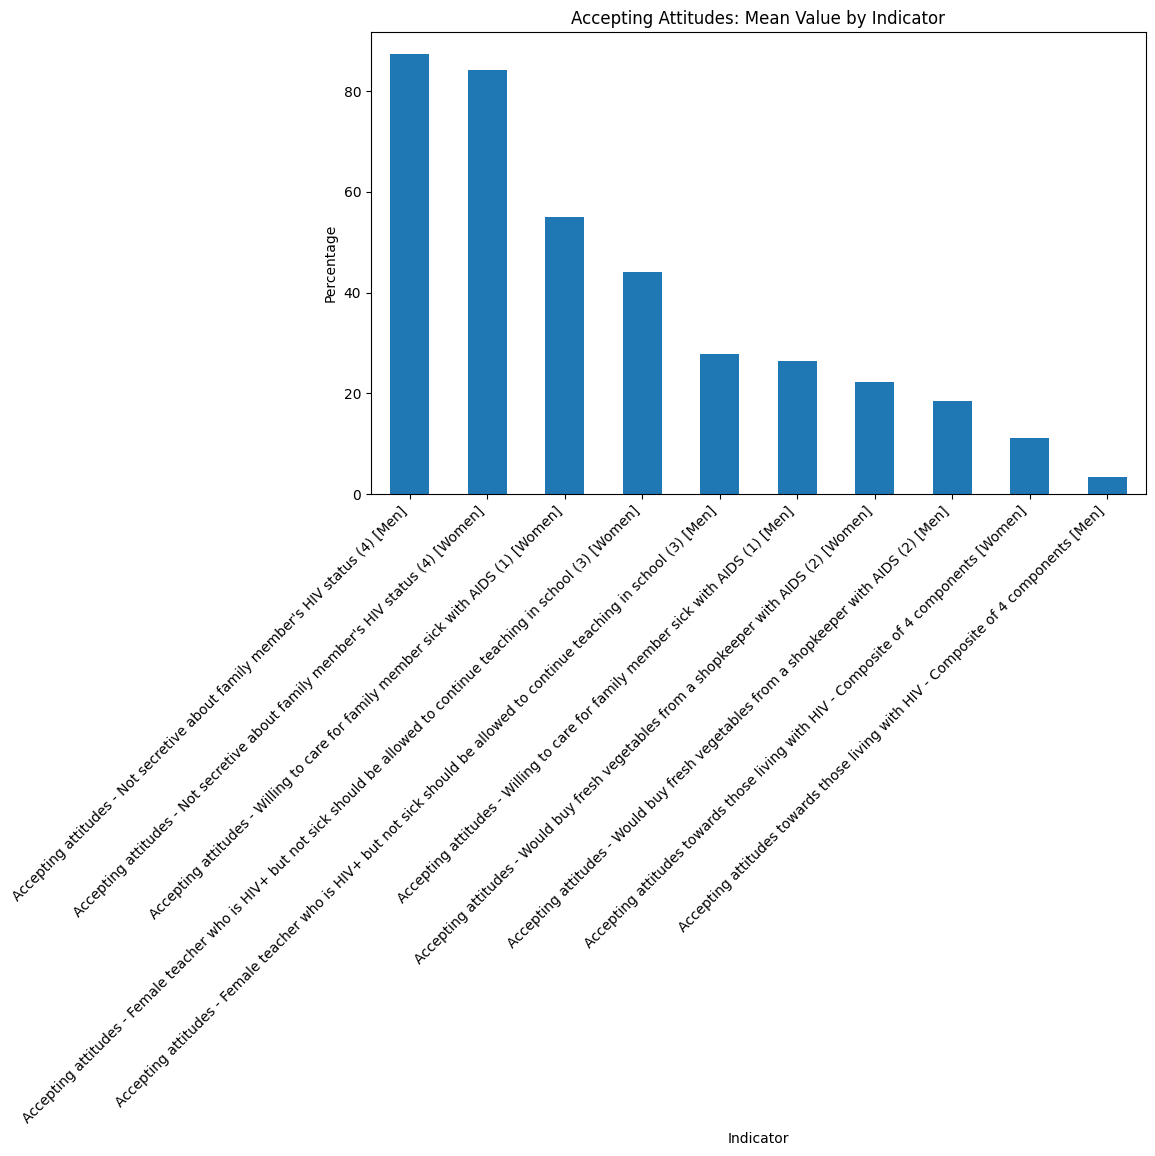

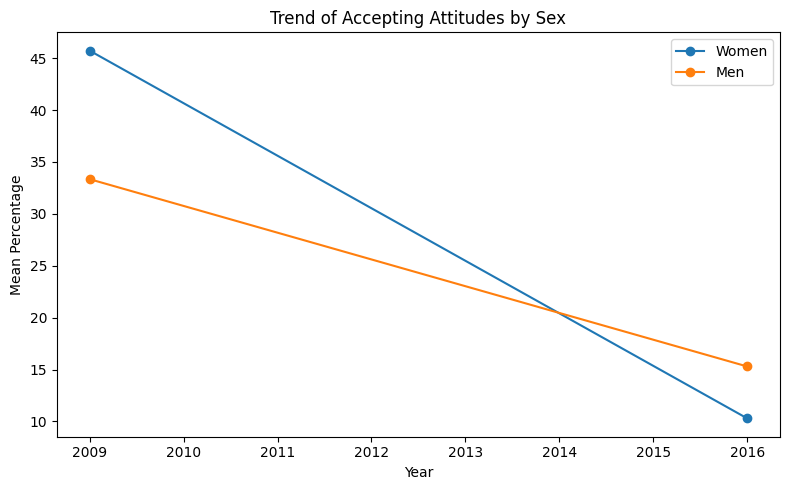

SurveyYearNum
2009.0    39.53
2016.0    12.80
Name: Value, dtype: float64

In [8]:
# CELL 7: Plots (matplotlib only)

# Bar chart: mean by indicator
plt.figure(figsize=(10,6))
accept_by_indicator.plot(kind='bar')
plt.title('Accepting Attitudes: Mean Value by Indicator')
plt.ylabel('Percentage')
plt.xlabel('Indicator')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Trend by Sex: mean per year for each sex
plt.figure(figsize=(8,5))
years = sorted(data_accept['SurveyYearNum'].unique())
for sex in ['Women','Men','Unknown']:
    subset = data_accept[data_accept['Sex']==sex].groupby('SurveyYearNum')['Value'].mean()
    if not subset.empty:
        plt.plot(subset.index, subset.values, marker='o', label=sex)
plt.title('Trend of Accepting Attitudes by Sex')
plt.xlabel('Year')
plt.ylabel('Mean Percentage')
plt.legend()
plt.tight_layout()
plt.show()

data_accept.groupby('SurveyYearNum')['Value'].mean()



In [9]:
# CELL 8: T-test comparing Men vs Women across AcceptingAttitude indicator values
men_accept = data_accept[data_accept['Sex']=='Men']['Value'].dropna()
women_accept = data_accept[data_accept['Sex']=='Women']['Value'].dropna()

print("n_men:", len(men_accept), "n_women:", len(women_accept))

if len(men_accept)>0 and len(women_accept)>0:
    t_stat, p_val = ttest_ind(women_accept, men_accept, equal_var=False, nan_policy='omit')
    print("t-statistic:", t_stat, "p-value:", p_val)
else:
    print("Not enough data for t-test.")


n_men: 6 n_women: 6
t-statistic: 0.5725782865892387 p-value: 0.579597921650794


In [10]:
# CELL 9: Chi-square on counts of Positive vs NotPositive (threshold 50%)
data_accept['AcceptCategory'] = data_accept['Value'].apply(lambda x: 'Positive' if x>50 else 'NotPositive')
cont_table = pd.crosstab(data_accept['SurveyYearNum'], data_accept['AcceptCategory'])
display(cont_table)

if cont_table.shape[0]>0 and cont_table.shape[1]>0:
    chi2, p, dof, expected = chi2_contingency(cont_table)
    print("Chi2:", chi2, "p-value:", p, "dof:", dof)
else:
    print("Not enough cells for chi-square.")


AcceptCategory,NotPositive,Positive
SurveyYearNum,,
2009.0,7,3
2016.0,2,0


Chi2: 0.0 p-value: 1.0 dof: 1


In [11]:
# CELL 10: Regression (OLS) with indicator fixed effects to estimate year effect
years_sorted = sorted(data['SurveyYearNum'].unique())
if len(years_sorted) >= 2:
    first, last = years_sorted[0], years_sorted[-1]
    data['YearDummyLast'] = (data['SurveyYearNum']==last).astype(int)
    reg_data = data[data['IndicatorType']=='AcceptingAttitude'].copy()
    # Fit OLS with Indicator fixed effects
    model = smf.ols('Value ~ YearDummyLast + C(Indicator)', data=reg_data).fit()
    print(model.summary())
else:
    print("Not enough years for regression.")


                            OLS Regression Results                            
Dep. Variable:                  Value   R-squared:                       0.991
Model:                            OLS   Adj. R-squared:                  0.902
Method:                 Least Squares   F-statistic:                     11.13
Date:                Wed, 17 Dec 2025   Prob (F-statistic):              0.229
Time:                        21:07:51   Log-Likelihood:                -28.078
No. Observations:                  12   AIC:                             78.16
Df Residuals:                       1   BIC:                             83.49
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                                                                                                                                                 coef    std err          t      P>|t|      [0.025      0.975]
---

In [12]:
# CELL 11: Filter sexual behaviour indicators
data_sex = data[data['IndicatorType']=='SexualBehaviour'].copy()
data_sex[['Indicator','SurveyYear','Sex','Value']].head(12)

# Descriptive
display(data_sex.groupby('Indicator')['Value'].describe())
display(data_sex.groupby('Sex')['Value'].mean())
display(data_sex.groupby('SurveyYearNum')['Value'].mean())


,count,mean,std,min,25%,50%,75%,max
Indicator,,,,,,,,
Woman is justified in asking that they use a condom if she knows that her husband has an sti [Men],1.0,42.0,NaN,42.0,42.0,42.0,42.0,42.0
Woman is justified in asking that they use a condom if she knows that her husband has an sti [Women],1.0,23.3,NaN,23.3,23.3,23.3,23.3,23.3
Woman is justified in refusing to have sexual intercourse with her husband if she knows he has sex with other women [Men],2.0,55.1,22.627417,39.1,47.1,55.1,63.1,71.1
Woman is justified in refusing to have sexual intercourse with her husband if she knows he has sex with other women [Women],2.0,49.6,21.496046,34.4,42.0,49.6,57.2,64.8


Sex
Men      50.733333
Women    40.833333
Name: Value, dtype: float64

SurveyYearNum
2009.0    67.95
2016.0    34.70
Name: Value, dtype: float64

C:\Users\Valente\AppData\Local\Temp\ipykernel_5396\4006247779.py:8: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


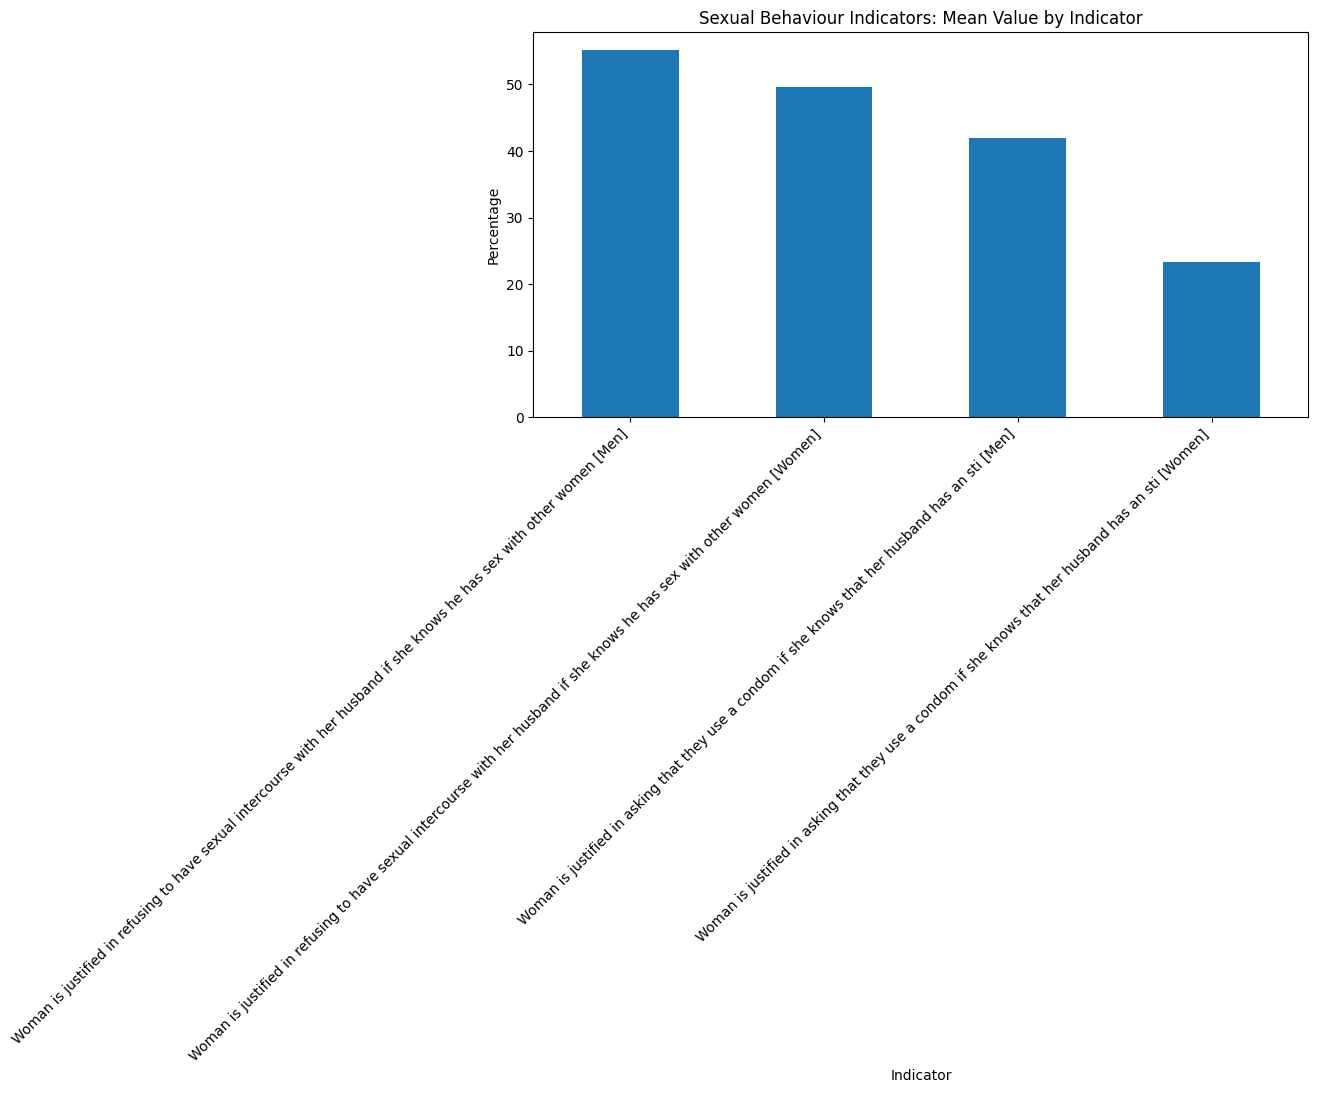

In [13]:
# CELL 12: Plot sexual behaviour means by indicator
plt.figure(figsize=(10,5))
sex_mean = data_sex.groupby('Indicator')['Value'].mean().sort_values(ascending=False)
sex_mean.plot(kind='bar')
plt.title('Sexual Behaviour Indicators: Mean Value by Indicator')
plt.ylabel('Percentage')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


In [14]:
# CELL 13: T-test for specific sexual behaviour indicator (refusing sex)
# Use substring match
refuse_w = data[data['Indicator'].str.lower().str.contains('refusing to have sexual intercourse') & (data['Sex']=='Women')]['Value'].dropna()
refuse_m = data[data['Indicator'].str.lower().str.contains('refusing to have sexual intercourse') & (data['Sex']=='Men')]['Value'].dropna()

print("n_women_refuse:", len(refuse_w), "n_men_refuse:", len(refuse_m))
if len(refuse_w)>0 and len(refuse_m)>0:
    t_stat_ref, p_ref = ttest_ind(refuse_w, refuse_m, equal_var=False, nan_policy='omit')
    print("t:", t_stat_ref, "p:", p_ref)
else:
    print("Not enough data for refuse-sex t-test.")


n_women_refuse: 2 n_men_refuse: 2
t: -0.24921855529807976 p: 0.8265041140422824


In [15]:
# CELL 14: Denominator analysis
data_den = data[data['IndicatorType']=='Denominator'].copy()
display(data_den[['Indicator','SurveyYear','DenominatorWeighted','DenominatorUnweighted']].drop_duplicates().sort_values('SurveyYear'))

# Summary of denominators across dataset
display(data[['SurveyYearNum','DenominatorWeighted','DenominatorUnweighted']].drop_duplicates().sort_values('SurveyYearNum'))


,Indicator,SurveyYear,DenominatorWeighted,DenominatorUnweighted
15,Number of women,2009,NaN,13137.0
16,Number of women (unweighted),2009,13137.0,NaN
18,Number of men,2009,NaN,4076.0
19,Number of men (unweighted),2009,4076.0,NaN
28,Number of women,2016,NaN,4305.0
29,Number of women (unweighted),2016,4305.0,NaN
32,Number of men,2016,NaN,4059.0
33,Number of men (unweighted),2016,4075.0,NaN


,SurveyYearNum,DenominatorWeighted,DenominatorUnweighted
0,2009.0,5748.0,5397.0
5,2009.0,NaN,5397.0
6,2009.0,5748.0,NaN
7,2009.0,2474.0,2442.0
12,2009.0,NaN,2442.0
13,2009.0,2474.0,NaN
14,2009.0,13137.0,13137.0
15,2009.0,NaN,13137.0
16,2009.0,13137.0,NaN
17,2009.0,4076.0,4076.0


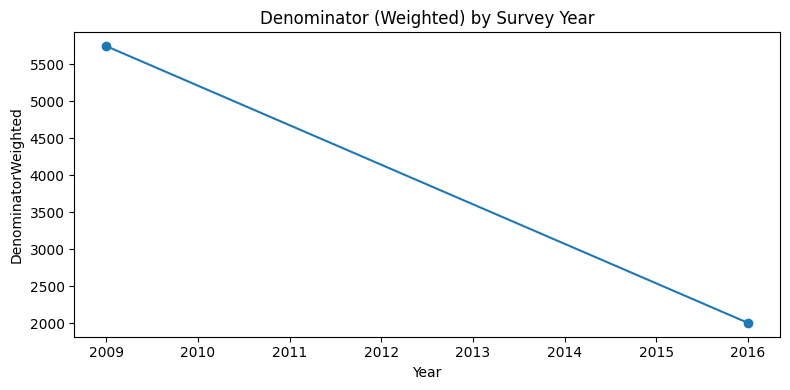

In [16]:
# CELL 15: Plot DenominatorWeighted by Year
plt.figure(figsize=(8,4))
den_by_year = data.groupby('SurveyYearNum')['DenominatorWeighted'].first().dropna()
if not den_by_year.empty:
    plt.plot(den_by_year.index, den_by_year.values, marker='o')
    plt.title('Denominator (Weighted) by Survey Year')
    plt.xlabel('Year')
    plt.ylabel('DenominatorWeighted')
    plt.tight_layout()
    plt.show()
else:
    print("No denominator values available for plotting.")


In [17]:
# CELL 16: Build change summary for Accepting Attitudes between first and last year (if possible)
years_sorted = sorted(data_accept['SurveyYearNum'].unique())
if len(years_sorted) >= 2:
    first, last = years_sorted[0], years_sorted[-1]
    pivot = data_accept.pivot_table(values='Value', index='Indicator', columns='SurveyYearNum')
    if first in pivot.columns and last in pivot.columns:
        change = pivot[last] - pivot[first]
        summary_change = pd.DataFrame({
            f'value_{first}': pivot[first],
            f'value_{last}': pivot[last],
            'change': change
        }).sort_values('change', ascending=False).reset_index()
        display(summary_change.head(20))
        # Save CSV for use in slides
        print("Saved summary to /mnt/data/accepting_attitudes_change_summary.csv")
    else:
        print("Pivot does not contain both years.")
else:
    print("Not enough years in accepting attitudes for change summary.")


,Indicator,value_2009.0,value_2016.0,change
0,Accepting attitudes - Would buy fresh vegetabl...,21.8,15.3,-6.5
1,Accepting attitudes - Would buy fresh vegetabl...,34.2,10.3,-23.9
2,Accepting attitudes - Female teacher who is HI...,27.8,NaN,NaN
3,Accepting attitudes - Female teacher who is HI...,44.2,NaN,NaN
4,Accepting attitudes - Not secretive about fami...,87.3,NaN,NaN
5,Accepting attitudes - Not secretive about fami...,84.1,NaN,NaN
6,Accepting attitudes - Willing to care for fami...,26.4,NaN,NaN
7,Accepting attitudes - Willing to care for fami...,55.0,NaN,NaN
8,Accepting attitudes towards those living with ...,3.4,NaN,NaN
9,Accepting attitudes towards those living with ...,11.1,NaN,NaN


Saved summary to /mnt/data/accepting_attitudes_change_summary.csv


In [18]:
# CELL 17: Prepare a few text strings you can paste into slides
text_intro = """
Data: DHS Timor-Leste — Attitudes toward people living with HIV.
Analisis: Descriptive, t-test (Men vs Women), chi-square (change in positive proportion), and regression with indicator fixed effects.
Catatan: Data ini summary-level (persentase indikator per tahun), bukan microdata individu.
"""
print(text_intro)

# Short conclusions template (fill numbers after running)
concl = """
1. Indikator accepting attitudes tertinggi: [nama indikator] = [nilai]%.
2. Indikator accepting attitudes terendah: [nama indikator] = [nilai]%.
3. Rata-rata accepting attitudes (Women) = [X]%, (Men) = [Y]%.
4. Hasil t-test Men vs Women: p = [p-value] → [interpretation].
5. Chi-square untuk perubahan proporsi positive antar tahun: p = [p-value] → [interpretation].
6. Regresi fixed effects: koefisien YearDummyLast = [coef], p = [p-val] → [interpretation].
"""
print(concl)



Data: DHS Timor-Leste — Attitudes toward people living with HIV.
Analisis: Descriptive, t-test (Men vs Women), chi-square (change in positive proportion), and regression with indicator fixed effects.
Catatan: Data ini summary-level (persentase indikator per tahun), bukan microdata individu.


1. Indikator accepting attitudes tertinggi: [nama indikator] = [nilai]%.
2. Indikator accepting attitudes terendah: [nama indikator] = [nilai]%.
3. Rata-rata accepting attitudes (Women) = [X]%, (Men) = [Y]%.
4. Hasil t-test Men vs Women: p = [p-value] → [interpretation].
5. Chi-square untuk perubahan proporsi positive antar tahun: p = [p-value] → [interpretation].
6. Regresi fixed effects: koefisien YearDummyLast = [coef], p = [p-val] → [interpretation].

